<h1> Geometric Operations and Other Mathematical Tools with Pillow</h1>


Estimated time needed: **40** minutes


<h2> Spatial Operations in Image Processing</h2>


Spatial operations use  pixels in a neighborhood to determine the present pixel value. Some applications include filtering and sharpening. They are used in many steps in computer vision, such as segmentation, and are a key building block in Artificial Intelligence algorithms.


- Linear Filtering
    - Filtering Noise
    - Gaussian Blur
    - Image Sharpening
- Edges
- Median


* * *


Download the images for the lab


In [1]:
!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg

!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png

!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100  7243  100  7243    0     0   4421      0  0:00:01  0:00:01 --:--:--  4427
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  1  462k    1  7514    0     0   4585      0  0:01:43  0:00:01  0:01:42  4590
  6  462k    6 31166    0     0  11584      0  0:00:40  0:00:02  0:00:38 11590
 13  462k   13 65536    0     0  19361      0  0:0

We will import the following libraries


In [ ]:
# Dùng để hiển thị hình ảnh
import matplotlib.pyplot as plt
# Dùng để xử lý hình ảnh
from PIL import Image
# Tạo ma trận (kernel) để xử lý ảnh / lọc ảnh
import numpy as np

This function will plot two images side by side 


In [3]:
# Hàm hiển thị 2 ảnh để so sánh (ảnh gốc và ảnh sau xử lý)
def plot_image(image_1, image_2, title_1="Orignal", title_2="New Image"):

    plt.figure(figsize=(10,10))  # tạo khung hiển thị ảnh

    plt.subplot(1, 2, 1)  # vị trí ảnh thứ 1
    plt.imshow(image_1)   # hiển thị ảnh gốc
    plt.title(title_1)

    plt.subplot(1, 2, 2)  # vị trí ảnh thứ 2
    plt.imshow(image_2)   # hiển thị ảnh mới / ảnh đã xử lý
    plt.title(title_2)

    plt.show()  # hiển thị tất cả lên màn hình

Spatial operations use the neighboring pixels to determine the present pixel value 


## Linear  Filtering


Filtering involves enhancing an image, for example, removing the noise from an image. Noise can be caused by a bad camera or bad image compression. The same factors that cause noise may lead to blurry images. We can apply filters to sharpen these images. Convolution is a standard way to filter an image. The filter is called the kernel and different kernels perform different tasks. In addition, Convolution is used for many of the most advanced artificial intelligence algorithms. We simply take the dot product of the kernel and an equally-sized portion of the image. We then shift the kernel and repeat.


Consider the following image:


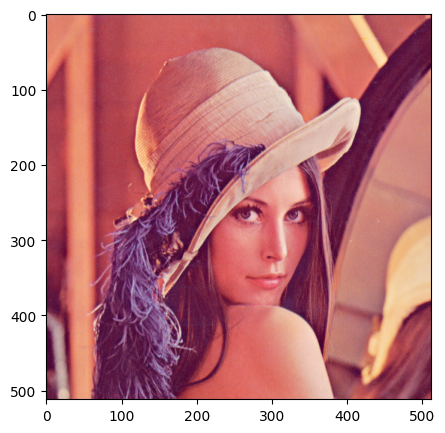

In [4]:
# Mở (load) ảnh từ file lenna.png
image = Image.open("lenna.png")

# Hiển thị ảnh
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.show()

The images we are working with are comprised of RGB values, which are values from 0 to 255. Zero means white noise, this makes the image look grainy:


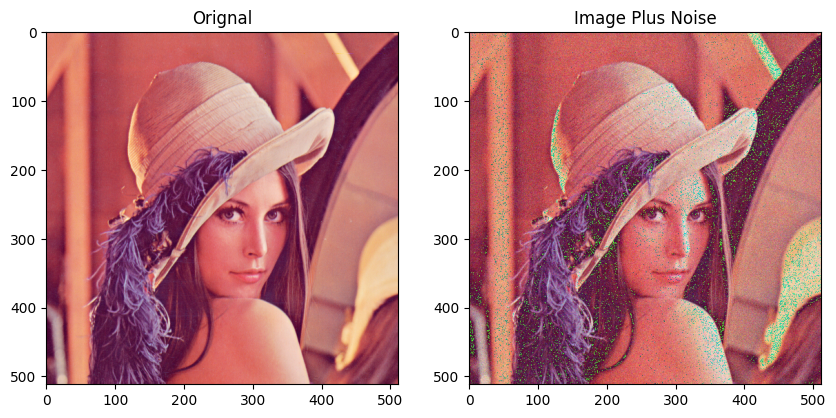

In [5]:
# Lấy kích thước ảnh (số hàng và cột)
rows, cols = image.size
# Tạo nhiễu ngẫu nhiên (noise) với phân phối chuẩn rồi chuyển về giá trị pixel 0-255
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Cộng nhiễu vào ảnh gốc
noisy_image = image + noise
# Chuyển mảng dữ liệu thành ảnh PIL
noisy_image = Image.fromarray(noisy_image)
# Hiển thị ảnh gốc và ảnh sau khi thêm nhiễu
plot_image(image, noisy_image, title_1="Orignal", title_2="Image Plus Noise")

When adding noise to an image sometimes the value might be greater than 255, in this case 256, is subtracted from the value to wrap the number around keeping it between 0 and 255. For example, consider an image with an RGB value of 137 and we add noise with an RGB value of 215 to get an RGB value of 352. We then subtract 256, the total number of possible values between 0 and 255, to get a number between 0 and 255.


### Filtering Noise


To be able to create customer kernels and use predefined filters we must import the following library


In [6]:
# Import thư viện dùng để áp dụng các bộ lọc (filter) cho ảnh
from PIL import ImageFilter

Smoothing filters average out the Pixels within a neighborhood, they are sometimes called low pass filters. For mean filtering, the  kernel simply averages out the kernels in a neighborhood.


In [7]:
# Tạo kernel 5x5, mỗi phần tử có giá trị 1/36 (dùng để làm mượt ảnh)
kernel = np.ones((5,5))/36

# Tạo bộ lọc Kernel của PIL từ ma trận kernel (flatten để chuyển thành 1 chiều)
kernel_filter = ImageFilter.Kernel((5,5), kernel.flatten())

The function <code>filter</code> performs a convolution between the image and the kernel on each color channel independently.


In [8]:
# Áp dụng bộ lọc kernel lên ảnh có nhiễu để làm mượt / giảm nhiễu
image_filtered = noisy_image.filter(kernel_filter)

We can plot the image before and after the filtering. We see the noise is reduced, but the image is blurry:


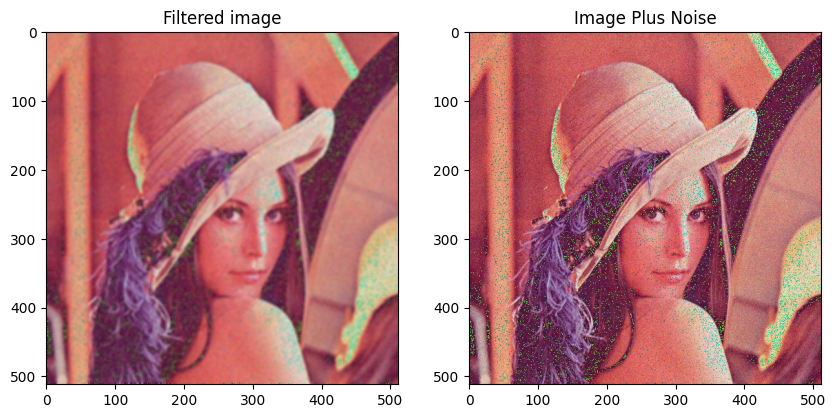

In [9]:
# Hiển thị ảnh sau khi lọc và ảnh có nhiễu để so sánh
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")

A smaller kernel keeps the image sharp, but filters less noise, here we try a 3x3 kernel. You can see her shoulders are sharper in this image but the green noise is brighter than the filtered image above.


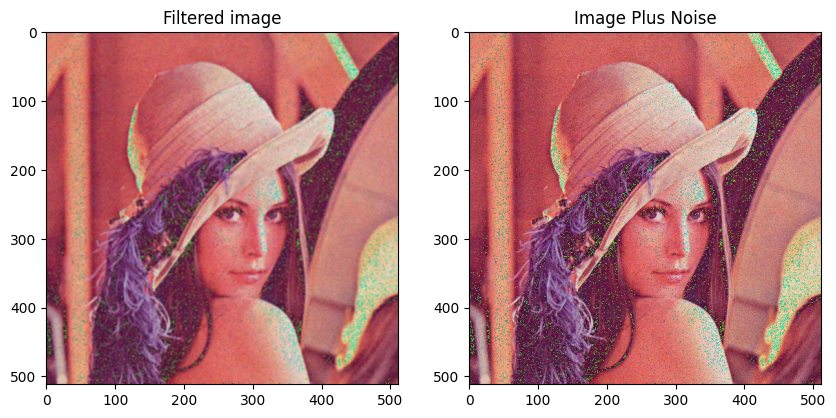

In [10]:
# Tạo kernel 3x3 để làm mượt ảnh
kernel = np.ones((3,3))/36

# Tạo bộ lọc kernel từ ma trận trên
kernel_filter = ImageFilter.Kernel((3,3), kernel.flatten())

# Áp dụng bộ lọc lên ảnh có nhiễu
image_filtered = noisy_image.filter(kernel_filter)

# Hiển thị ảnh sau khi lọc và ảnh có nhiễu để so sánh
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")

### Gaussian Blur


To perform Gaussian Blur we use the `filter` function on an image using the predefined filter `ImageFilter.GaussianBlur`


Parameters

<p><code>radius</code>: blur kernel radius, default 2</p>


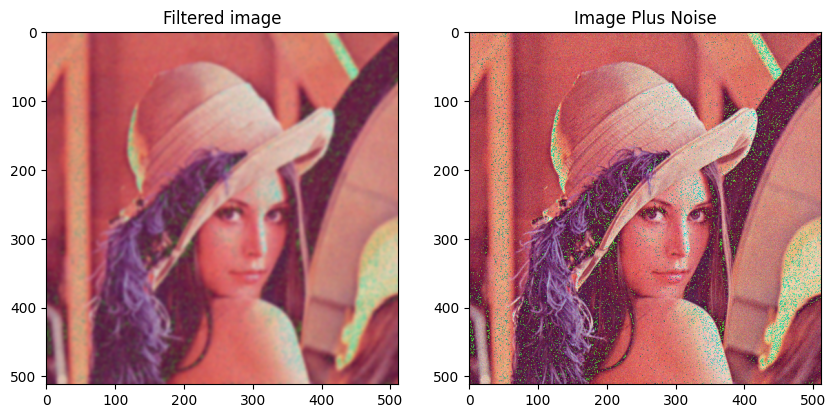

In [11]:
# Áp dụng bộ lọc GaussianBlur để làm mờ / giảm nhiễu ảnh
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur)

# Hiển thị ảnh sau khi lọc và ảnh có nhiễu để so sánh
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")

Lets try using a 4 by 4 kernel


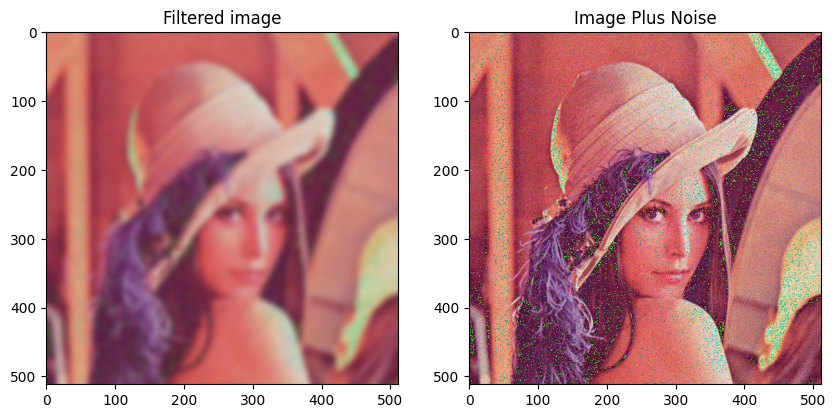

In [12]:
# Áp dụng bộ lọc GaussianBlur với mức làm mờ 4 để giảm nhiễu
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur(4))

# Hiển thị ảnh sau khi lọc và ảnh có nhiễu để so sánh
plot_image(image_filtered, noisy_image, title_1="Filtered image", title_2="Image Plus Noise")

### Image Sharpening


Image Sharpening involves smoothing the image and calculating the derivatives.  We can accomplish image sharpening by applying the following Kernel.


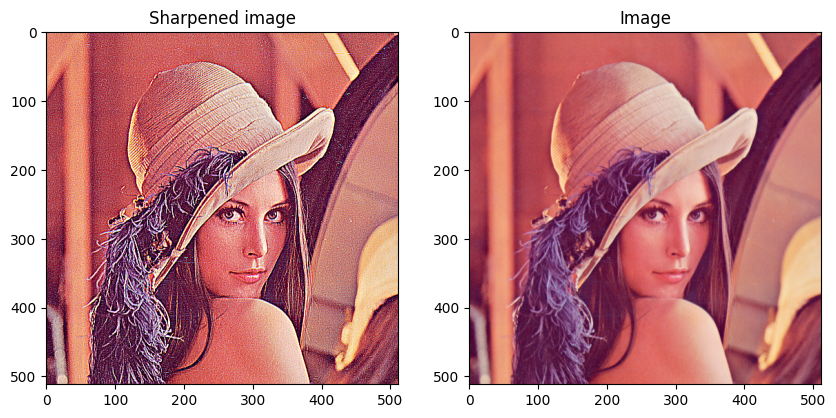

In [13]:
# Tạo kernel 3x3 dùng để làm sắc nét (sharpen) ảnh
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1],
                   [-1,-1,-1]])

# Tạo bộ lọc kernel từ ma trận trên
kernel = ImageFilter.Kernel((3,3), kernel.flatten())

# Áp dụng bộ lọc làm sắc nét lên ảnh gốc
sharpened = image.filter(kernel)

# Hiển thị ảnh sau khi sharpen và ảnh gốc để so sánh
plot_image(sharpened, image, title_1="Sharpened image", title_2="Image")

We can also sharpen using a predefined filter


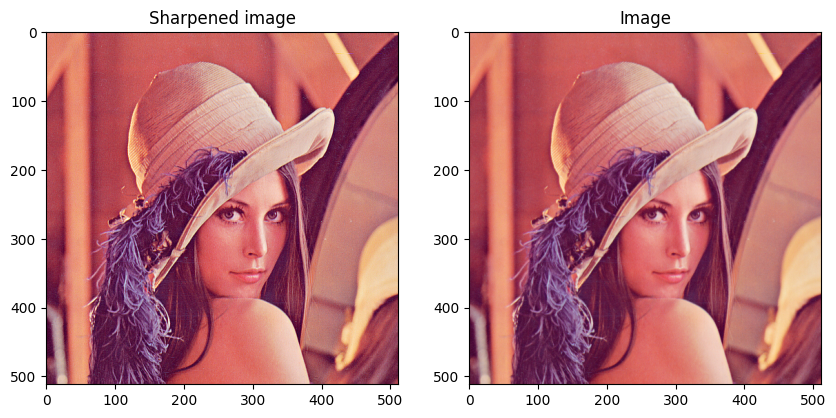

In [14]:
# Dùng bộ lọc SHARPEN có sẵn của PIL để làm sắc nét ảnh
sharpened = image.filter(ImageFilter.SHARPEN)

# Hiển thị ảnh sau khi sharpen và ảnh gốc để so sánh
plot_image(sharpened, image, title_1="Sharpened image", title_2="Image")

## Edges


Edges are where pixel intensities change. The Gradient of a function outputs the rate of change; we can approximate the gradient of a grayscale image with convolution. Consider the following image:


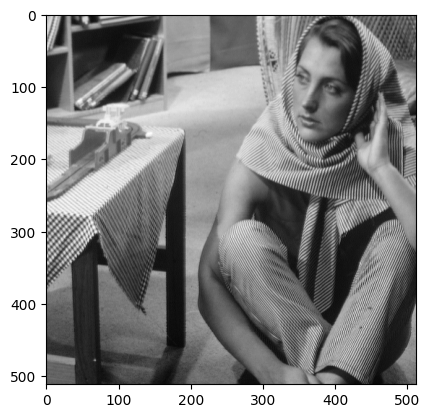

In [15]:
# Mở ảnh barbara.png (ảnh xám)
img_gray = Image.open('barbara.png')

# Hiển thị ảnh xám, dùng cmap='gray' vì ảnh chỉ có 1 kênh màu
plt.imshow(img_gray, cmap='gray')

We enhance the edges so they are better picked up when we use edge detection


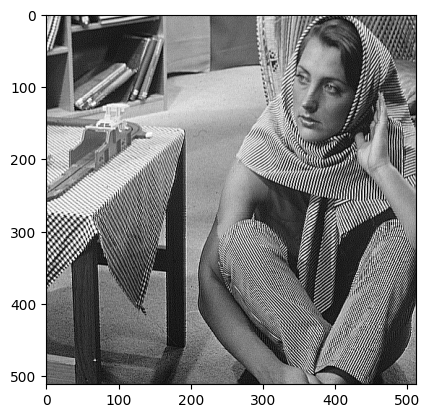

In [16]:
# Dùng bộ lọc EDGE_ENHANCE để làm nổi bật các cạnh trong ảnh
img_gray = img_gray.filter(ImageFilter.EDGE_ENHANCE)

# Hiển thị ảnh sau khi tăng cường cạnh
plt.imshow(img_gray, cmap='gray')

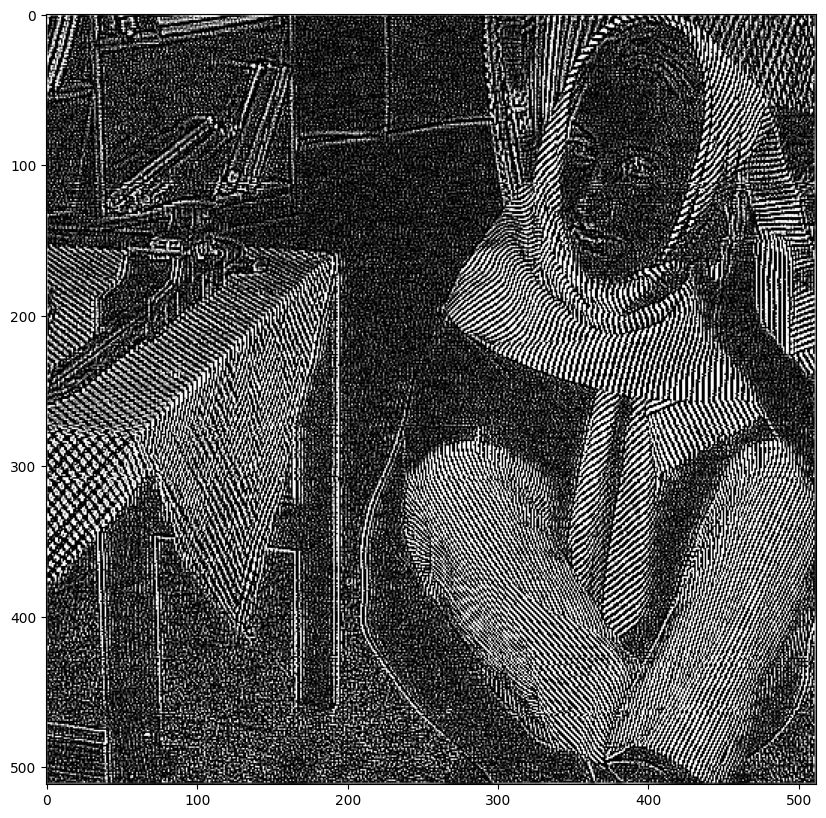

In [17]:
# Dùng bộ lọc FIND_EDGES để phát hiện các cạnh trong ảnh
img_gray = img_gray.filter(ImageFilter.FIND_EDGES)

# Hiển thị ảnh sau khi phát hiện cạnh
plt.figure(figsize=(10,10))
plt.imshow(img_gray, cmap='gray')

## Median

Median filters find the median of all the pixels under the kernel area and the central element is replaced with this median value. 


We can apply median filters to regular images but let’s see how we can use a median filter to improve segmentation. Consider the cameraman example: 


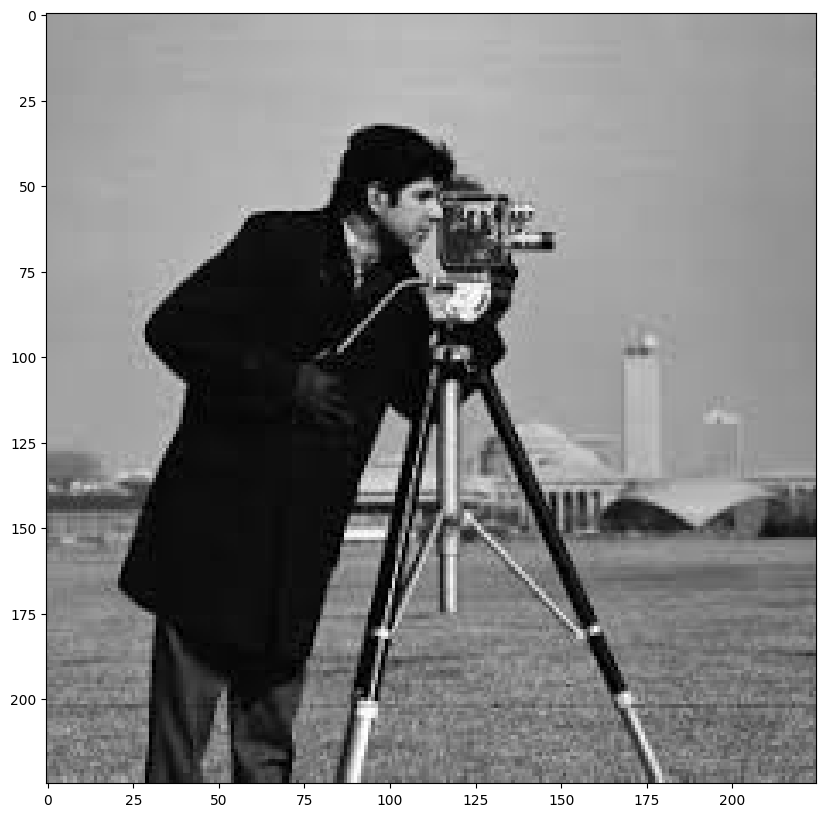

In [18]:
# Mở ảnh cameraman.jpeg
image = Image.open("cameraman.jpeg")

# Tăng kích thước khung hiển thị
plt.figure(figsize=(10,10))

# Hiển thị ảnh (dùng thang màu xám)
plt.imshow(image, cmap="gray")

Median filtering blurs the background, increasing the segmentation between the cameraman and the background


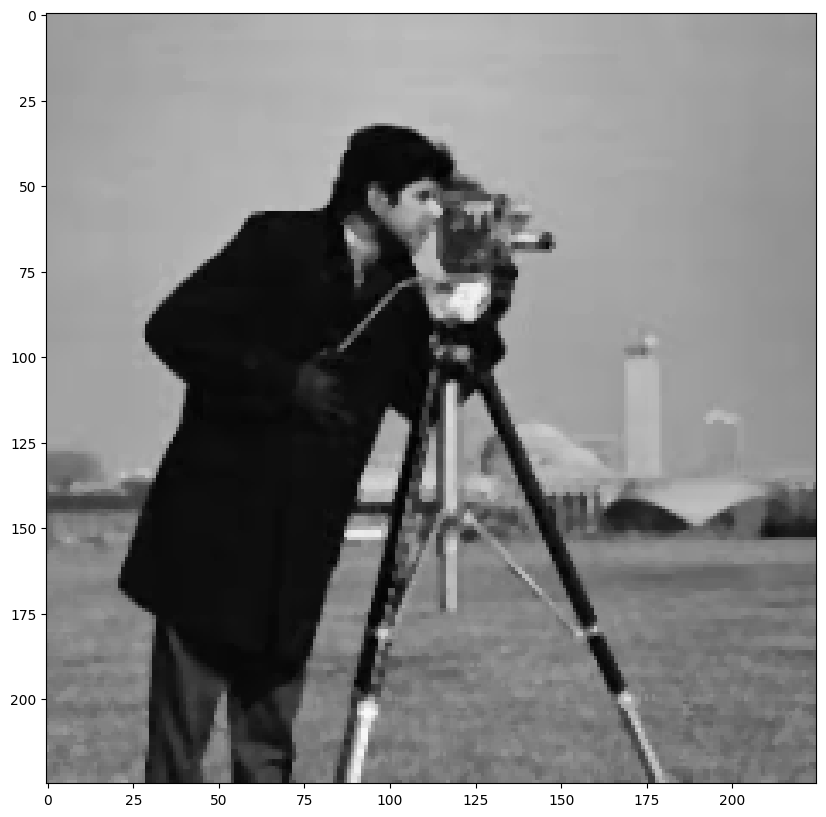

In [19]:
# Dùng MedianFilter để giảm nhiễu (lọc trung vị)
image = image.filter(ImageFilter.MedianFilter)

# Tăng kích thước khung hiển thị
plt.figure(figsize=(10,10))

# Hiển thị ảnh sau khi lọc
plt.imshow(image, cmap="gray")

# References


[1]  Images were taken from: [https://homepages.cae.wisc.edu/~ece533/images/](https://homepages.cae.wisc.edu/~ece533/images/?utm_email=Email&utm_source=Nurture&utm_content=000026UJ&utm_term=10006555&utm_campaign=PLACEHOLDER&utm_id=SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-CV0101EN-Coursera-25797139)

[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.
